# MitoChontrol Tutorial

This notebook demonstrates two end-to-end workflows for applying
**MitoChontrol** mitochondrial RNA thresholding to a single-cell RNA-seq
dataset.

| Workflow | Description |
|---|---|
| **A — Clustered pipeline** | `clustering()` → `mtctrl_with_clustering()` — clusters the sample first, then applies per-cluster naive-Bayes thresholds. This is the recommended approach when distinct sub-populations are expected. |
| **B — Single-cluster pipeline** | `mtctrl_without_clustering()` — treats the entire sample as one population and applies thresholds directly. Useful for already-isolated cell types or quick exploration. |

Both workflows start from the **same raw counts** and produce:
- Boolean threshold columns in `adata.obs` (`True` = flagged for removal)
- Threshold statistics (probability, threshold value, cells lost/retained)
- Diagnostic plots (UMAPs, naive-Bayes fits, enrichment comparisons)

---

## 0 — Setup

Import the three main entry-point functions from the `mitochontrol` package,
plus standard helpers for data loading and visualization.

In [1]:
from pathlib import Path

import anndata as ad
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

from mitochontrol import clustering, mtctrl_with_clustering, mtctrl_without_clustering

### Configuration

Adjust the paths and parameters below to match your setup.

| Variable | Purpose |
|---|---|
| `INPUT_H5AD` | Path to the raw-count `.h5ad` file |
| `SAMPLE_LABEL` | Short name used in output file names |
| `OUTDIR` | Root folder for all outputs |
| `OUTDIR_A` | Output folder for Workflow A (clustered pipeline) |
| `OUTDIR_B` | Output folder for Workflow B (single-cluster pipeline) |
| `THRESHOLD_PROBS` | Posterior-probability cutoffs for naive-Bayes thresholding |

In [2]:
INPUT_H5AD = Path("adata/raw_filtered_healthy.h5ad")
SAMPLE_LABEL = "Healthy"
OUTDIR = Path("MitoChontrol_tut_output")
OUTDIR_A = OUTDIR / "clustered_pipeline"
OUTDIR_B = OUTDIR / "single_cluster_pipeline"
THRESHOLD_PROBS = (0.8,)

---

## 1 — Load and inspect the raw data

The input file should contain **raw (integer) counts** in `adata.X`.  
No preprocessing, normalization, or clustering is expected at this stage.

In [3]:
adata_raw = ad.read_h5ad(INPUT_H5AD)
adata_raw.var_names_make_unique()

print(f"Loaded {adata_raw.n_obs:,} cells × {adata_raw.n_vars:,} genes")
print(f"Layers present:  {list(adata_raw.layers.keys()) or '(none)'}")
print(f"X dtype / type:  {adata_raw.X.dtype} / {type(adata_raw.X).__name__}")
print(f"obs columns:     {list(adata_raw.obs.columns)}")
print(f"obsm keys:       {list(adata_raw.obsm.keys()) or '(none)'}")

Loaded 5,406 cells × 36,601 genes
Layers present:  (none)
X dtype / type:  float32 / csc_matrix
obs columns:     ['Filtered']
obsm keys:       (none)


---

# Workflow A — Clustered Pipeline

This workflow first clusters the sample with `clustering()`, then feeds the
clustered result into `mtctrl_with_clustering()` for **per-cluster** mitochondrial
thresholding.

### Why cluster first?

Different cell types have different baseline mitochondrial expression levels.
Clustering before thresholding lets MitoChontrol fit a separate Gaussian
mixture model to each cluster, producing more accurate and cell-type-aware
thresholds.

## A1 — Run `clustering()`

The `clustering()` function handles the full clustering pipeline in a single
call:

1. **Detects raw counts** — if `adata.X` contains integer-like values, they
   are copied into a `raw_counts` layer automatically.
2. **Creates an analysis layer** — normalizes and log-transforms the raw
   counts into a `lognorm` layer (warns if this step is needed).
3. **Constructs a neighbor graph** — excludes mitochondrial (`MT-`) and
   ribosomal (`RPS`, `RPL`, `MRPS`, `MRPL`) genes.
4. **Selects an optimal Leiden resolution** — sweeps a resolution range and
   picks the value that maximizes graph modularity.
5. **Runs Leiden clustering and UMAP**.
6. **Computes top 50 DEGs per cluster** (Wilcoxon).
7. **Optionally assigns cell types** if `marker_genes` is provided.

All artifacts are written under `{OUTDIR}/clustered/`.

#### Key parameters

| Parameter | Default | Description |
|---|---|---|
| `raw_layer` | `None` (auto-detect) | Name of the layer with raw counts |
| `analyzed_layer` | `None` (auto-create) | Name of the analysis layer |
| `marker_genes` | `None` | Path to a marker-gene CSV for cell-type assignment |
| `n_neighbors` | 30 | Neighbors for the kNN graph |
| `n_pcs` | 30 | Number of PCs used for neighbors |
| `show` | `False` | Whether to display plots inline |

/Users/strasscm/Documents/Research/Mitochontrol_Codebase/mitochontrol/clustering.py:680: UserWarning: Warning: adata did not contain preprocessed counts. Running normalization and log-transformation now
  analyzed_layer_name = _resolve_analyzed_layer(
/Users/strasscm/miniconda3/envs/mitochontrol_tut/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/strasscm/Documents/Research/Mitochontrol_Codebase/mitochontrol/clustering.py:302: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


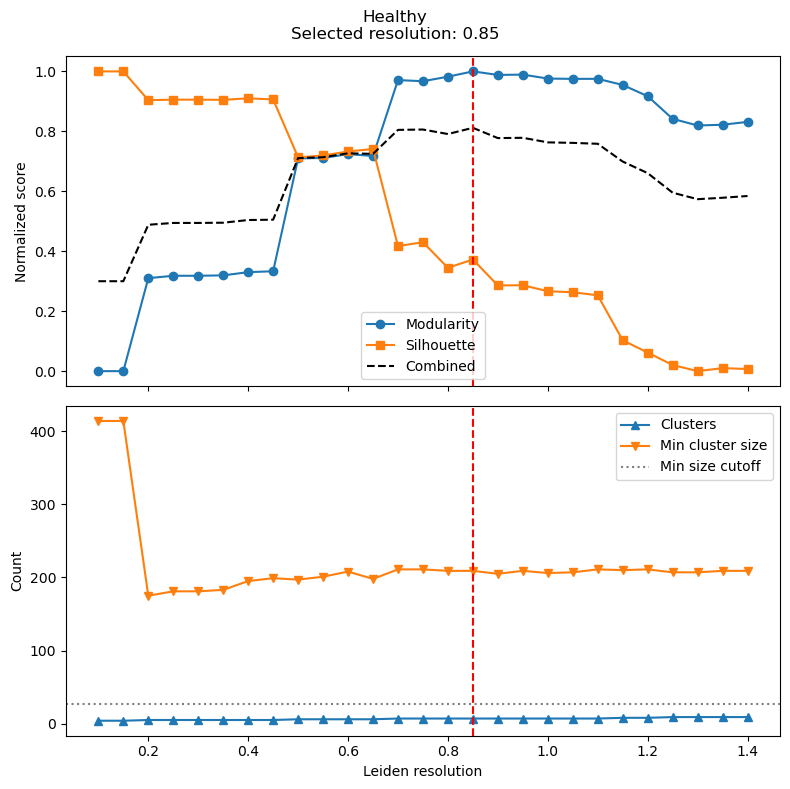

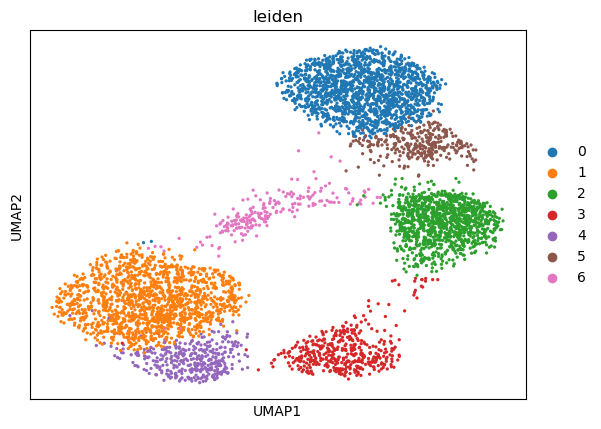

In [4]:
clustered_result = clustering(
    adata_raw.copy(),
    label=SAMPLE_LABEL,
    outdir=OUTDIR_A,
    show=True,
)

### Inspect clustering output

`clustering()` returns a dictionary with the following keys:

| Key | Type | Description |
|---|---|---|
| `adata` | `AnnData` | The clustered object with `obs['leiden']` and UMAP coordinates |
| `resolution` | `float` | The selected Leiden resolution |
| `n_clusters` | `int` | Number of clusters found |
| `raw_layer` | `str` | Name of the raw-count layer |
| `analyzed_layer` | `str` | Name of the analysis layer |
| `deg` | `DataFrame` | Top DEGs per cluster |
| `celltype_labels` | `DataFrame` or `None` | Cell-type assignments (if marker genes were provided) |
| `paths` | `dict` | File paths to all saved artifacts |

In [5]:
print(f"Resolution:       {clustered_result['resolution']:.2f}")
print(f"Clusters found:   {clustered_result['n_clusters']}")
print(f"Raw layer:        {clustered_result['raw_layer']}")
print(f"Analyzed layer:   {clustered_result['analyzed_layer']}")
print(f"Leiden values:    {sorted(clustered_result['adata'].obs['leiden'].unique())}")
print()
print("Layers in adata:", list(clustered_result['adata'].layers.keys()))
print()
print("Saved artifacts:")
for name, path in clustered_result['paths'].items():
    exists = Path(path).exists()
    print(f"  {name:12s} → {path}  {'✓' if exists else '(not found)'}")

Resolution:       0.85
Clusters found:   7
Raw layer:        raw_counts
Analyzed layer:   lognorm
Leiden values:    ['0', '1', '2', '3', '4', '5', '6']

Layers in adata: ['raw_counts', 'lognorm']

Saved artifacts:
  adata        → MitoChontrol_tut_output/clustered_pipeline/clustered/adata/Healthy.h5ad  ✓
  umap         → MitoChontrol_tut_output/clustered_pipeline/clustered/umap/Healthy.pdf  ✓
  res          → MitoChontrol_tut_output/clustered_pipeline/clustered/res_selection/Healthy.pdf  ✓
  deg          → MitoChontrol_tut_output/clustered_pipeline/clustered/DEG/Healthy.csv  ✓
  labels       → MitoChontrol_tut_output/clustered_pipeline/clustered/celltype_labels/Healthy.csv  (not found)


In [6]:
clustered_result["deg"].head(10)

,leiden,rank,gene,scores,logfoldchanges,pvals,pvals_adj
0,0,1,XIST,45.289402,2.726974,0.000000e+00,0.000000e+00
1,0,2,PRKG1,41.917274,2.504943,0.000000e+00,0.000000e+00
2,0,3,TSIX,40.008083,2.995344,0.000000e+00,0.000000e+00
3,0,4,AUTS2,39.942093,2.395615,0.000000e+00,0.000000e+00
4,0,5,GPC6,38.817757,2.406614,0.000000e+00,0.000000e+00
5,0,6,FTX,37.113083,2.162172,1.728264e-301,6.951229e-299
6,0,7,FHIT,37.034500,2.449286,3.189966e-300,1.242084e-297
7,0,8,LRBA,36.871063,1.981001,1.344683e-297,5.126744e-295
8,0,9,RAD51B,36.781395,2.168790,3.662413e-296,1.340480e-293
9,0,10,MT-ND3,36.701393,1.794251,6.939183e-295,2.514664e-292


---

## A1b — Cell-type annotation (optional)

MitoChontrol's `clustering()` function can **automatically assign cell types**
if you provide a marker-gene file via the `marker_genes` parameter. Cell-type
labels are stored in `adata.obs['celltype']` and written to
`{outdir}/clustered/celltype_labels/{label}.csv`.

You can either:

1. **Re-run `clustering()` with `marker_genes`** (replaces the call in A1):

```python
clustered_result = clustering(
    adata_raw.copy(),
    label=SAMPLE_LABEL,
    outdir=OUTDIR_A,
    marker_genes="path/to/marker_genes.csv",
    show=True,
)
```

2. **Call `assign_celltypes()` on the existing result** (shown in the cell
   below) — useful when you want to iterate on marker genes without
   re-clustering.

### Marker-gene CSV format

The file should have **no header row**. Each row is one cell type, with the
label in the first column and marker genes in subsequent columns:

```
T cell,CD3D,CD3E,CD2
B cell,CD79A,MS4A1,CD19
Monocyte,CD14,LYZ,S100A8
NK cell,NKG7,GNLY,KLRD1
```

The assignment algorithm compares each cluster's **top 50 DEGs** against
the marker sets and picks the cell type with the greatest overlap.

In [7]:
from mitochontrol import assign_celltypes

# --- Set MARKER_GENES to a CSV path or a dict to enable cell typing ---
# Examples:
#   MARKER_GENES = Path("marker_genes.csv")
#   MARKER_GENES = {
#       "T cell": ["CD3D", "CD3E", "CD2"],
#       "B cell": ["CD79A", "MS4A1", "CD19"],
#       "Monocyte": ["CD14", "LYZ", "S100A8"],
#   }
MARKER_GENES = None  # set to a path or dict to enable

if MARKER_GENES is not None:
    adata_clustered = clustered_result["adata"]
    deg_df = clustered_result["deg"]
    labels_df = assign_celltypes(
        adata_clustered,
        deg_df,
        marker_genes=MARKER_GENES,
        output_path=OUTDIR_A / "clustered" / "celltype_labels" / f"{SAMPLE_LABEL}.csv",
    )
    display(labels_df)
    sc.pl.umap(adata_clustered, color=["leiden", "celltype"], ncols=2, frameon=False, show=True)
else:
    print("Skipping cell-type annotation (MARKER_GENES is None).")
    print("Set MARKER_GENES above to a CSV path or dict to enable.")

Skipping cell-type annotation (MARKER_GENES is None).
Set MARKER_GENES above to a CSV path or dict to enable.


---

## A2 — Run `mtctrl_with_clustering()`

Now pass the clustering result into `mtctrl_with_clustering()`. This function:

1. **Ensures `mt_frac` exists** — computes the mitochondrial-count fraction
   from raw counts if the column is missing.
2. **Fits a 2-component GMM** to each cluster's `mt_frac` distribution.
3. **Applies naive-Bayes thresholds** at each probability in
   `THRESHOLD_PROBS`, creating boolean columns
   `mitochontrol_threshold_out_{prob}` where `True` = flagged for removal.
4. **Runs comparative enrichment** analysis per cluster per threshold.
5. **Saves** diagnostic plots and a `threshold_stats.csv` summary.

#### Output directory layout

```
{OUTDIR_A}/clustered/...            — clustering artifacts
{OUTDIR_A}/mitochontrol/
├── adata/{label}.h5ad              — thresholded AnnData
├── cluster_overlays/{label}.pdf    — cluster overlay plots
├── threshold/{label}_cluster{n}_{prob}.pdf
├── enrichment/{label}_cluster{n}_{prob}.pdf
├── filtered_umap/{label}_cluster{n}_{prob}.pdf
└── threshold_stats.csv             — per-cluster threshold statistics
```

In [8]:
threshold_results = mtctrl_with_clustering(
    adatas={SAMPLE_LABEL: clustered_result},
    outdir=OUTDIR_A,
    threshold_probs=THRESHOLD_PROBS,
    show=False,
    save=True,
)

### Inspect threshold results

`mtctrl_with_clustering()` returns a dictionary keyed by sample label. Each entry
contains:

| Key | Type | Description |
|---|---|---|
| `adata` | `AnnData` | The final thresholded object |
| `thresholds` | `dict` | Per-cluster threshold values (cluster → prob → value) |
| `threshold_stats` | `DataFrame` | Summary statistics for every cluster × threshold |

If any clusters are completely filtered, apply one of the three heuristics:
1. Retain Entire Cluster
2. Filter Entire Cluster
3. Conventional 10% Threshold

In [9]:
sample_result = threshold_results[SAMPLE_LABEL]
adata_thresholded = sample_result["adata"]
cluster_stats = sample_result["threshold_stats"]
display(cluster_stats)

check_clusters = cluster_stats[cluster_stats["cells_retained"] == 0]

if len(check_clusters) == 0:
    print("No clusters are completely filtered — no heuristic needed.")
elif len(check_clusters) == 1:
    print(f"Cluster {check_clusters.iloc[0]['cluster_id']} is completely filtered.")
else:
    cids = ", ".join(str(c) for c in check_clusters["cluster_id"])
    print(f"Clusters {cids} are completely filtered.")



,adata_label,cluster_id,post_prob_compromise,threshold_value,cells_lost,cells_retained
0,Healthy,0,0.8,0.317893,1566,0
1,Healthy,1,0.8,10.201198,38,1392
2,Healthy,2,0.8,8.106134,449,645
3,Healthy,3,0.8,13.272297,48,386
4,Healthy,4,0.8,10.401339,10,359
5,Healthy,5,0.8,0.418410,304,0
6,Healthy,6,0.8,7.099711,65,144


Clusters 0, 5 are completely filtered.


### Heuristic overrides for completely-filtered clusters

When the naive-Bayes threshold is so low that an entire cluster is flagged
(`cells_retained == 0`), the threshold is likely uninformative for that
cluster. Edit `HEURISTIC_CHOICES` below to assign a heuristic **per cluster**:

| Code | Heuristic | Effect |
|---|---|---|
| `1` | **Retain Entire Cluster** | Set all cells to `False` (retained). Use when the cluster is biologically meaningful and its mtRNA profile is acceptable. |
| `2` | **Filter Entire Cluster** | Keep all cells as `True` (flagged). Use when the cluster is suspected to be debris or low-quality. |
| `3` | **Conventional 10% Threshold** | Replace the naive-Bayes threshold with a flat `CONVENTIONAL_CUTOFF` mtRNA cutoff. A middle ground that removes only clearly compromised cells. |

After the overrides are applied, the adjusted `adata` and an updated
`threshold_stats.csv` (with a new `heuristic` column) are saved to
`{OUTDIR}/mitochontrol/post_heuristics/`.

In [ ]:
# ---------- USER CONFIGURATION ----------
# Map each completely-filtered cluster to a heuristic (1, 2, or 3).
# Only clusters listed in check_clusters need an entry.
HEURISTIC_CHOICES = {
    "0": 1,   # cluster 0 → retain entire cluster
    "5": 3,   # cluster 5 → conventional 10% cutoff
}
CONVENTIONAL_CUTOFF = 10.0  # percent mtRNA (used by heuristic 3)
# -----------------------------------------

HEURISTIC_LABELS = {
    1: "retain_entire_cluster",
    2: "filter_entire_cluster",
    3: f"conventional_{CONVENTIONAL_CUTOFF:g}pct",
}

updated_stats = cluster_stats.copy()
updated_stats["heuristic"] = "naive_bayes"

for _, row in check_clusters.iterrows():
    cid = str(row["cluster_id"])
    choice = HEURISTIC_CHOICES.get(cid)
    if choice is None:
        print(f"  Cluster {cid}: no heuristic specified — skipping")
        continue

    prob = row["post_prob_compromise"]
    col = f"mitochontrol_threshold_out_{prob:g}"
    mask = adata_thresholded.obs["leiden"] == cid
    n_total = int(mask.sum())

    if choice == 1:
        adata_thresholded.obs.loc[mask, col] = False
        cells_lost, cells_retained = 0, n_total
        new_thresh = float("nan")
        print(f"  Cluster {cid}: Retain — all {n_total} cells kept")

    elif choice == 2:
        cells_lost, cells_retained = n_total, 0
        new_thresh = row["threshold_value"]
        print(f"  Cluster {cid}: Filter — all {n_total} cells removed")

    elif choice == 3:
        mt = adata_thresholded.obs.loc[mask, "mt_frac"].astype(float)
        new_flags = mt > CONVENTIONAL_CUTOFF
        adata_thresholded.obs.loc[mask, col] = new_flags.values
        cells_lost = int(new_flags.sum())
        cells_retained = n_total - cells_lost
        new_thresh = CONVENTIONAL_CUTOFF
        print(
            f"  Cluster {cid}: {CONVENTIONAL_CUTOFF:g}% cutoff — "
            f"{cells_lost}/{n_total} flagged, {cells_retained} retained"
        )
    else:
        print(f"  Cluster {cid}: unknown heuristic {choice} — skipping")
        continue

    idx = updated_stats[
        updated_stats["cluster_id"].astype(str) == cid
    ].index
    updated_stats.loc[idx, "threshold_value"] = new_thresh
    updated_stats.loc[idx, "cells_lost"] = cells_lost
    updated_stats.loc[idx, "cells_retained"] = cells_retained
    updated_stats.loc[idx, "heuristic"] = HEURISTIC_LABELS[choice]

post_dir = OUTDIR_A / "mitochontrol" / "post_heuristics"
post_dir.mkdir(parents=True, exist_ok=True)
adata_thresholded.write(post_dir / f"{SAMPLE_LABEL}.h5ad")
updated_stats.to_csv(post_dir / "threshold_stats.csv", index=False)

print(f"\nSaved to {post_dir}/")
display(updated_stats)

  Cluster 0: Retain — all 1566 cells kept
  Cluster 5: no heuristic specified — skipping

Saved to MitoChontrol_tut_output/clustered_pipeline/mitochontrol/post_heuristics/


,adata_label,cluster_id,post_prob_compromise,threshold_value,cells_lost,cells_retained,heuristic
0,Healthy,0,0.8,NaN,0,1566,retain_entire_cluster
1,Healthy,1,0.8,10.201198,38,1392,naive_bayes
2,Healthy,2,0.8,8.106134,449,645,naive_bayes
3,Healthy,3,0.8,13.272297,48,386,naive_bayes
4,Healthy,4,0.8,10.401339,10,359,naive_bayes
5,Healthy,5,0.8,0.418410,304,0,naive_bayes
6,Healthy,6,0.8,7.099711,65,144,naive_bayes


In [11]:
print("Threshold columns added to adata.obs (after heuristic override):")
threshold_cols = [c for c in adata_thresholded.obs.columns if c.startswith("mitochontrol_threshold_out")]
for col in threshold_cols:
    n_flagged = adata_thresholded.obs[col].sum()
    n_total = adata_thresholded.n_obs
    print(f"  {col}: {n_flagged:,} / {n_total:,} cells flagged ({100 * n_flagged / n_total:.1f}%)")

Threshold columns added to adata.obs (after heuristic override):
  mitochontrol_threshold_out_0.8: 914 / 5,406 cells flagged (16.9%)


In [12]:
print(f"Post-heuristic threshold statistics ({len(updated_stats)} rows):")
updated_stats

Post-heuristic threshold statistics (7 rows):


,adata_label,cluster_id,post_prob_compromise,threshold_value,cells_lost,cells_retained,heuristic
0,Healthy,0,0.8,NaN,0,1566,retain_entire_cluster
1,Healthy,1,0.8,10.201198,38,1392,naive_bayes
2,Healthy,2,0.8,8.106134,449,645,naive_bayes
3,Healthy,3,0.8,13.272297,48,386,naive_bayes
4,Healthy,4,0.8,10.401339,10,359,naive_bayes
5,Healthy,5,0.8,0.418410,304,0,naive_bayes
6,Healthy,6,0.8,7.099711,65,144,naive_bayes


In [13]:
print("Per-cluster threshold values:")
for cluster_id, probs in sorted(sample_result["thresholds"].items(), key=lambda x: int(x[0])):
    for prob, value in probs.items():
        print(f"  Cluster {cluster_id}, prob {prob}: mt_frac threshold = {value:.4f}")

Per-cluster threshold values:
  Cluster 0, prob 0.8: mt_frac threshold = 0.3179
  Cluster 1, prob 0.8: mt_frac threshold = 10.2012
  Cluster 2, prob 0.8: mt_frac threshold = 8.1061
  Cluster 3, prob 0.8: mt_frac threshold = 13.2723
  Cluster 4, prob 0.8: mt_frac threshold = 10.4013
  Cluster 5, prob 0.8: mt_frac threshold = 0.4184
  Cluster 6, prob 0.8: mt_frac threshold = 7.0997


### Visualize the result

Plot the UMAP colored by `leiden` cluster labels alongside each threshold
column. Cells marked `True` (flagged for removal) are highlighted.

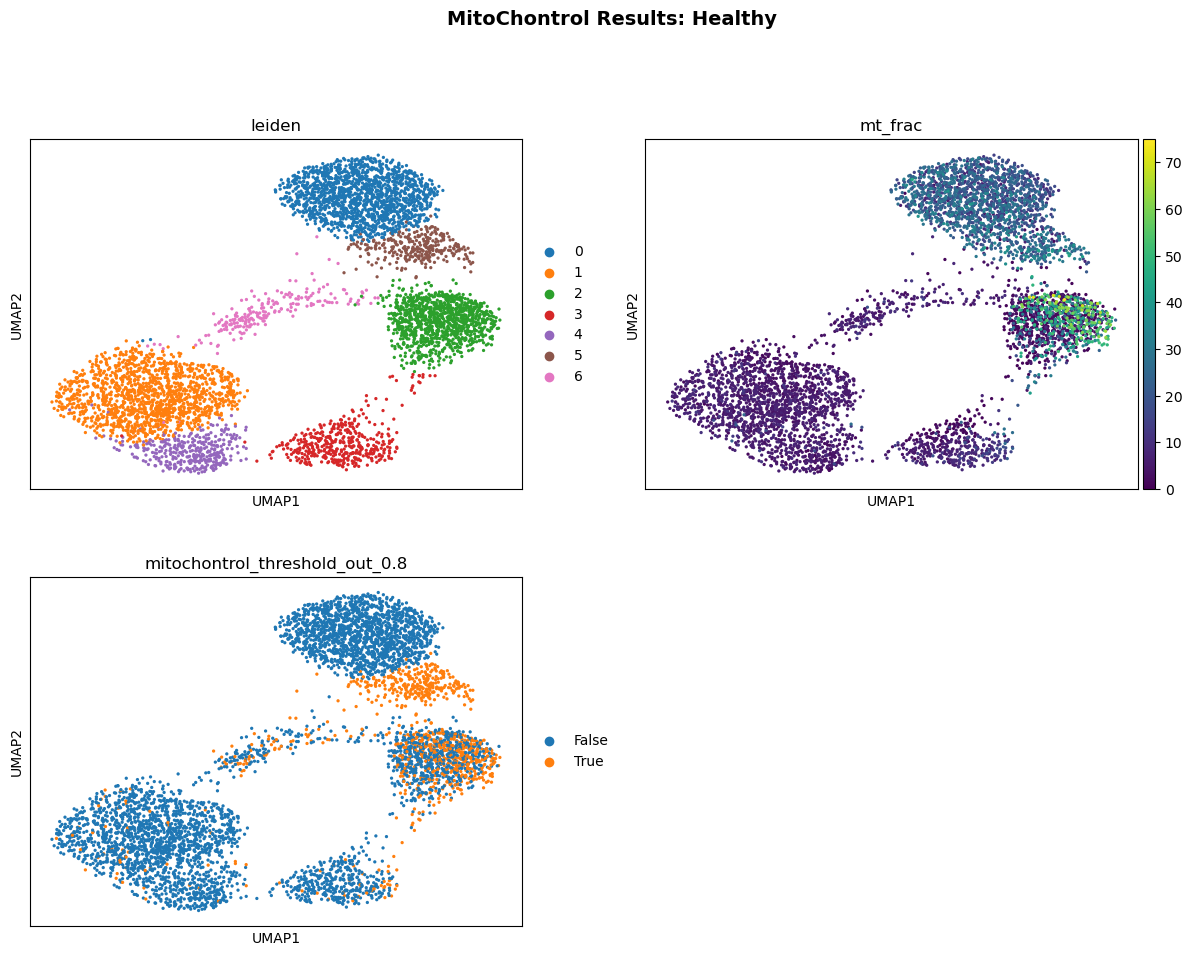

In [14]:
plot_cols = ["leiden", "mt_frac"] + threshold_cols
fig = sc.pl.umap(
    adata_thresholded,
    color=plot_cols,
    ncols=2,
    frameon=True,
    show=False,
    return_fig=True,
    title=plot_cols,
)
fig.suptitle(
    f"MitoChontrol Results: {SAMPLE_LABEL}",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.show()

### Data preparation

Unlike `clustering()`, `mtctrl_without_clustering()` expects
the input `AnnData` to already have:
- Raw counts accessible (in `adata.X` or a layer such as `raw_counts`)

No Leiden labels or UMAP are required. With `save=True`, the function
writes mt-vs-UMI scatter plots under `mitochontrol/scatter/` (initial and
per-threshold colored).

We normalize `adata.X` below for a typical Scanpy-style matrix; the
thresholding step reads mitochondrial content from the raw layer.


## B1 — Reload fresh raw data and prepare

We reload the original file to start from a clean slate. The preparation
steps mirror what `clustering()` does internally, but without the Leiden
resolution search.

In [15]:
adata_single = ad.read_h5ad(INPUT_H5AD)
adata_single.var_names_make_unique()

print(f"Reloaded {adata_single.n_obs:,} cells × {adata_single.n_vars:,} genes")
print(f"X dtype: {adata_single.X.dtype}")

Reloaded 5,406 cells × 36,601 genes
X dtype: float32


### Preserve raw counts

Copy the raw count matrix into a named layer so it is not overwritten during
normalization. `mtctrl_without_clustering()` uses these raw counts to
compute `mt_frac`.

In [16]:
adata_single.layers["raw_counts"] = adata_single.X.copy()
print(f"Saved raw counts to layer 'raw_counts'  (shape: {adata_single.layers['raw_counts'].shape})")

Saved raw counts to layer 'raw_counts'  (shape: (5406, 36601))


### Normalize and log-transform

Overwrite `adata.X` with normalized, log-transformed values (optional but
typical for downstream RNA analysis). `mtctrl_without_clustering()` still
uses the `raw_counts` layer for `mt_frac` and does **not** require PCA or
UMAP.


In [17]:
sc.pp.normalize_total(adata_single, target_sum=1e4)
sc.pp.log1p(adata_single)

print(f"X is now log-normalized  (max value: {adata_single.X.max():.2f})")

X is now log-normalized  (max value: 7.46)


### Embeddings

Unlike workflow A, the single-cluster pipeline does **not** compute or use
UMAP. Diagnostic figures are mt-vs-UMI scatters from
`plot_mt_by_umi` (called inside `mtctrl_without_clustering`).


In [ ]:
# No PCA / neighbors / UMAP required for mtctrl_without_clustering.
print("Proceeding without UMAP (scatter-only diagnostics).")


In [ ]:
# Optional: quick view of normalized expression (gene space).
# sc.pl.highest_expr_genes(adata_single, n_top=10, show=True)
pass


---

## B2 — Run `mtctrl_without_clustering()`

This function:

1. **Computes `mt_frac`** from raw counts if the column is missing.
2. **Plots** an initial mt-vs-UMI scatter (`plot_mt_by_umi`).
3. **Fits a 2-component GMM** to the sample's `mt_frac` distribution.
4. **Applies naive-Bayes thresholds** at each specified probability.
5. **Runs comparative enrichment** analysis.
6. **Saves** threshold PDFs, enrichment PDFs, and **threshold-colored**
   mt-vs-UMI scatters under `mitochontrol/scatter/` (no UMAP).

We pre-compute `mt_frac` from the **raw counts** layer before calling the
function, since `adata.X` has already been log-normalized.

#### Output directory layout

```
{OUTDIR_B}/mitochontrol/
├── adata/{label}.h5ad
├── threshold/{label}_{prob}.pdf
├── enrichment/{label}_{prob}.pdf
├── scatter/{label}_mt_by_umi.png
├── scatter/{label}_mt_by_umi_thresh_{prob}.png
```

Note the absence of `cluster{n}` in the filenames compared to Workflow A.


mt_frac computed from raw counts: mean=13.06%, median=7.14%


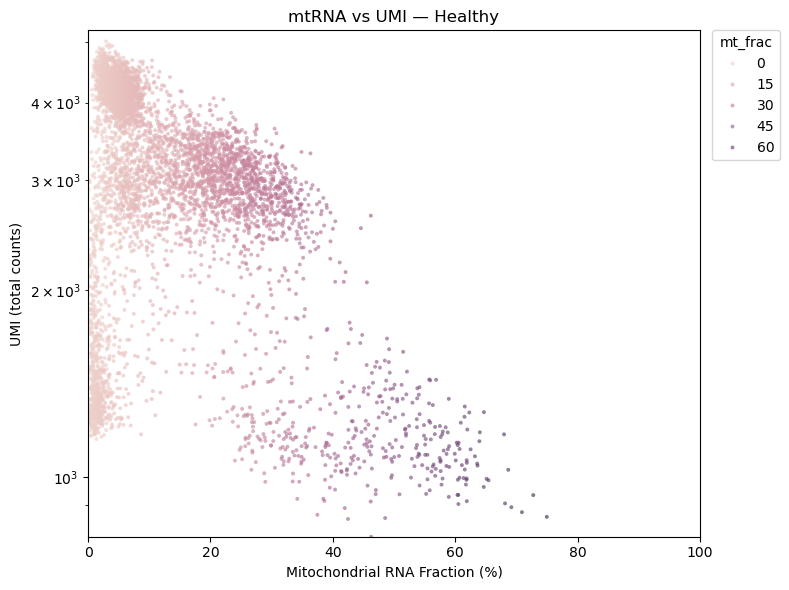

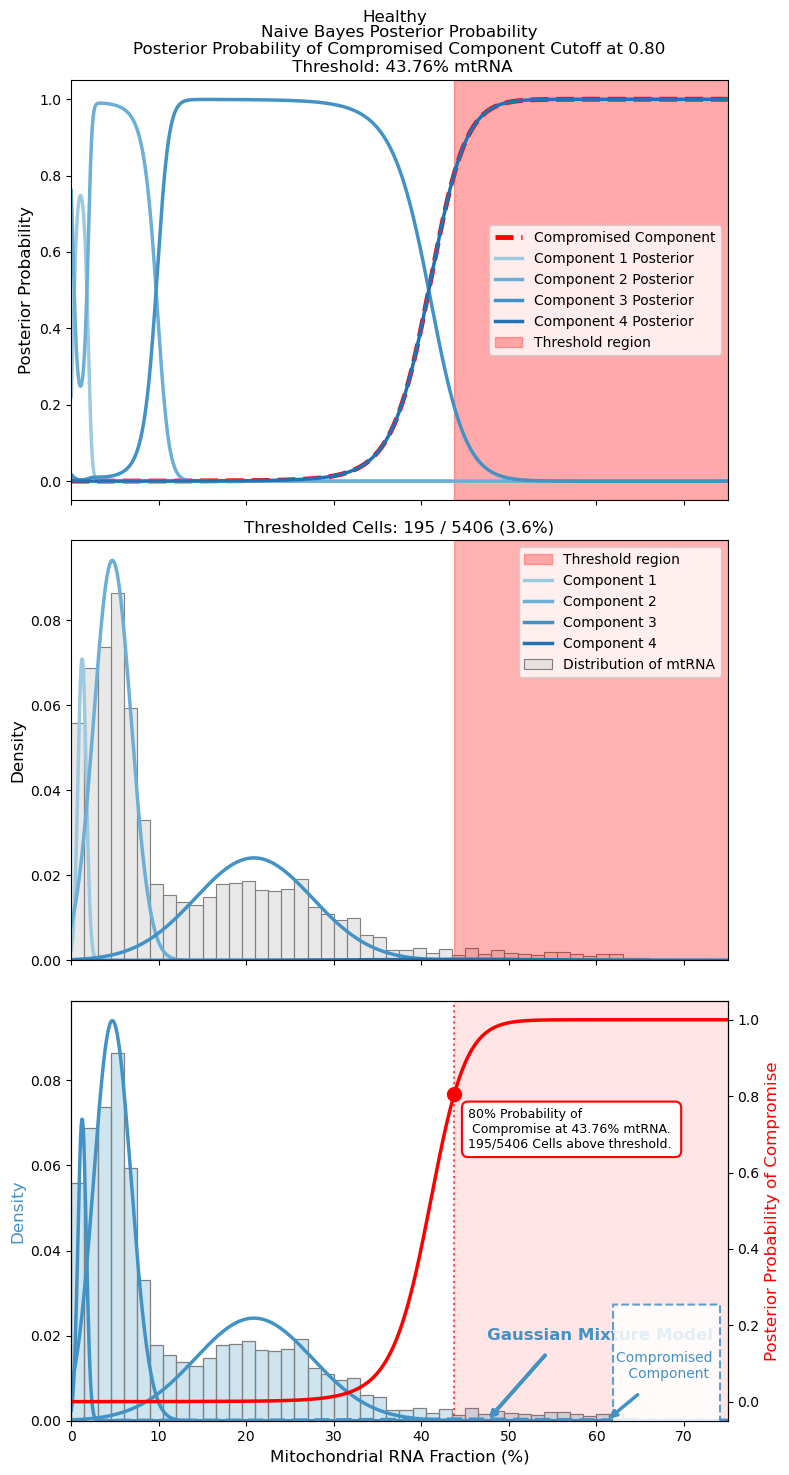

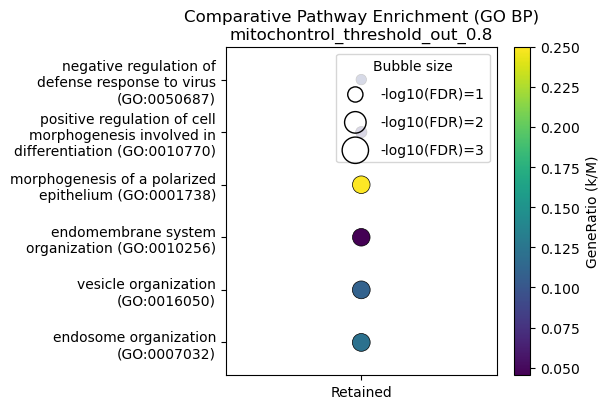

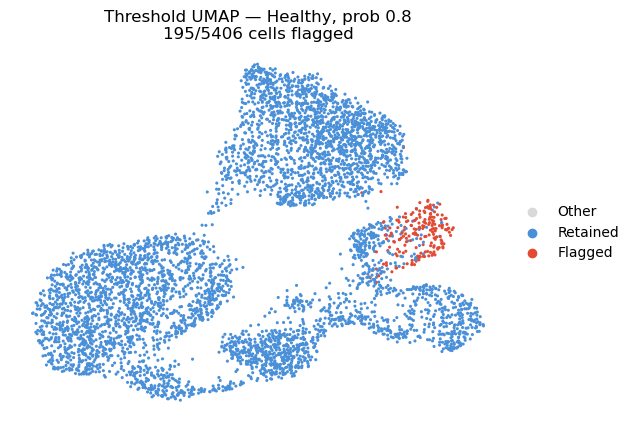

  adata_label cluster_id  post_prob_compromise  threshold_value  cells_lost  \
0     Healthy                               0.8         43.75811         195   

   cells_retained  
0            5211  


In [20]:
# Compute mt_frac from the raw counts layer (X is log-normalized)
import numpy as np
from scipy import sparse as sp

raw = adata_single.layers["raw_counts"]
mt_mask = adata_single.var_names.str.upper().str.startswith("MT-")
if sp.issparse(raw):
    total = np.asarray(raw.sum(axis=1)).ravel()
    mt_total = np.asarray(raw[:, mt_mask].sum(axis=1)).ravel()
else:
    total = raw.sum(axis=1)
    mt_total = raw[:, mt_mask].sum(axis=1)
adata_single.obs["mt_frac"] = np.where(
    total > 0, 100.0 * mt_total / total, 0.0
)
print(f"mt_frac computed from raw counts: "
      f"mean={adata_single.obs['mt_frac'].mean():.2f}%, "
      f"median={adata_single.obs['mt_frac'].median():.2f}%")

single_cluster_stats = mtctrl_without_clustering(
    adata_single,
    sample_id=SAMPLE_LABEL,
    outdir=OUTDIR_B,
    show=True,
    save=True,
    threshold_probs=THRESHOLD_PROBS,
)

### Inspect single-cluster results

`mtctrl_without_clustering()` returns a `DataFrame` of threshold
statistics. The threshold columns are also added directly to the input
`adata_single.obs`.

In [ ]:
display(single_cluster_stats)

Stats rows: 1


,adata_label,cluster_id,post_prob_compromise,threshold_value,cells_lost,cells_retained
0,Healthy,,0.8,43.75811,195,5211


In [22]:
print("Threshold columns in adata_single.obs:")
sc_threshold_cols = [c for c in adata_single.obs.columns if c.startswith("mitochontrol_threshold_out")]
for col in sc_threshold_cols:
    n_flagged = adata_single.obs[col].sum()
    n_total = adata_single.n_obs
    print(f"  {col}: {n_flagged:,} / {n_total:,} cells flagged ({100 * n_flagged / n_total:.1f}%)")

Threshold columns in adata_single.obs:
  mitochontrol_threshold_out_0.8: 195 / 5,406 cells flagged (3.6%)


In [ ]:
from mitochontrol.visualization import plot_mt_by_umi

plot_mt_by_umi(adata_single, color_by="mt_frac", show=True, save=False)
for col in sc_threshold_cols:
    plot_mt_by_umi(
        adata_single,
        color_by=col,
        show=True,
        save=False,
        title=f"{SAMPLE_LABEL}: mtRNA vs UMI ({col})",
    )


---

# Summary

| | Workflow A (clustered) | Workflow B (single-cluster) |
|---|---|---|
| **Entry point** | `clustering()` → `mtctrl_with_clustering()` | `mtctrl_without_clustering()` |
| **Clustering** | Automatic (Leiden) | None |
| **Thresholding** | Per-cluster GMM + naive Bayes | Whole-sample GMM + naive Bayes |
| **Output columns** | `mitochontrol_threshold_out_{prob}` | `mitochontrol_threshold_out_{prob}` |
| **When to use** | Multiple cell types; heterogeneous mt levels | Homogeneous population; quick exploration |

### Next steps

- Adjust `THRESHOLD_PROBS` to explore different stringency levels
  (e.g. `(0.6, 0.75, 0.9)`).
- Provide a `marker_genes` CSV to `clustering()` for automatic cell-type
  annotation.
- Filter the thresholded `AnnData` for downstream analysis:

```python
adata_clean = adata_thresholded[~adata_thresholded.obs["mitochontrol_threshold_out_0.8"]].copy()
```